<a href="https://colab.research.google.com/github/Jayvish80/Tesla-Stock-Price-Prediction-Using-LSTM-RNN/blob/main/Tesla_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  Tesla Stock Price Prediction


##### **Project Type**    - Basic Python, Data Visualization, Data Cleaning, EDA, NLP, Deep Learning (SimpleRNN and LSTM)

##### **Contribution**    - Individual

# **Project Summary -**


- This internship project focuses on building a deep learning–based time series forecasting system to predict the closing price behavior of Tesla Inc.’s stock. The stock market is highly dynamic and influenced by multiple factors, making accurate price prediction a challenging yet valuable task in the financial services domain. The primary objective of this project is to analyze historical Tesla stock data and develop predictive models using Recurrent Neural Network (SimpleRNN) and Long Short-Term Memory (LSTM) architectures to forecast stock closing prices for short-term horizons of 1 day, 5 days, and 10 days.

- The dataset used in this project consists of historical Tesla stock prices, including features such as Date, Open, High, Low, Close, Adjusted Close, and Volume. Since stock price data is sequential and time-dependent in nature, traditional machine learning techniques are insufficient to capture long-term temporal dependencies. Therefore, deep learning models specifically designed for sequence learning, such as SimpleRNN and LSTM, were selected for this task. The project emphasizes predicting the closing price, as it is one of the most critical indicators used by investors and traders for decision-making.

- The project began with a thorough understanding of the problem statement and business use cases, including automated trading strategies, risk management, portfolio optimization, and financial forecasting. Data preprocessing played a crucial role in ensuring model accuracy and reliability. This phase involved loading the dataset, handling missing values, converting the date column into a datetime format, and setting it as an index. To improve model convergence and performance, data scaling was performed using normalization techniques such as MinMaxScaler. Time-series sequences were then created using a sliding window approach, enabling the models to learn patterns from historical price movements.

- Two deep learning models were developed and compared: SimpleRNN and LSTM. Both models were implemented using the TensorFlow Keras Sequential API. The architectures included recurrent layers to capture sequential dependencies, dropout layers to prevent overfitting, and dense output layers to generate price predictions. The models were compiled using Mean Squared Error (MSE) as the loss function and optimized using the Adam optimizer. Hyperparameter tuning was performed using GridSearchCV to identify optimal values for parameters such as the number of hidden units, dropout rate, and learning rate.

- Model training was conducted with techniques such as early stopping and model checkpointing to ensure efficient learning and avoid overfitting. The trained models were evaluated on unseen test data using error metrics like Mean Squared Error and through visual comparison of actual versus predicted stock prices. The comparative analysis revealed that the LSTM model consistently outperformed the SimpleRNN model due to its ability to retain long-term dependencies and handle vanishing gradient issues more effectively.

- In conclusion, this project demonstrates the practical application of deep learning techniques in financial time-series forecasting. While the models show promising results, limitations such as market volatility and the exclusion of external factors like news sentiment remain. Future enhancements may include incorporating alternative data sources, advanced architectures such as GRU or Transformers, and real-time deployment using Streamlit. Overall, this project provides valuable insights into stock price prediction and strengthens skills in data preprocessing, exploratory data analysis, deep learning modeling, and model evaluation.

# **GitHub Link -**

https://github.com/Jayvish80/Tesla-Stock-Price-Prediction-Using-LSTM-RNN.git

# **Problem Statement**

- Stock price prediction is a complex task due to the time-dependent and volatile nature of financial markets. Traditional methods often struggle to capture sequential patterns in stock data. This project aims to develop deep learning–based time-series models using SimpleRNN and LSTM to predict the closing price of Tesla stock for 1-day, 5-day, and 10-day horizons. By preprocessing historical stock data, handling missing values, and tuning model hyperparameters, the project compares the performance of SimpleRNN and LSTM models to identify the most effective approach for short-term stock price forecasting.


# ***Let's Begin!***

### **Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


In [ ]:
# warnings ignore
import warnings
warnings.filterwarnings("ignore")

### **Load Dataset**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Tesla Stock Price Prediction/TSLA.csv")
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### **Basic Data Exploration**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [ ]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


### **Data Cleaning**

In [ ]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Set Date as index
df.set_index('Date', inplace=True)

# Check missing values
df.isnull().sum()


,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
# Handle missing values (time-series friendly)
df.fillna(method='ffill', inplace=True)


### **Select Target Feature (Closing Price)**

In [ ]:
data = df[['Close']]
data.head()


,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


### **Data Visualization**

In [ ]:
df = df.copy()
df.index = pd.to_datetime(df.index)
df.reset_index(inplace=True)
df.rename(columns={'index': 'Date'}, inplace=True)


##### CHART 1 – Closing Price Trend

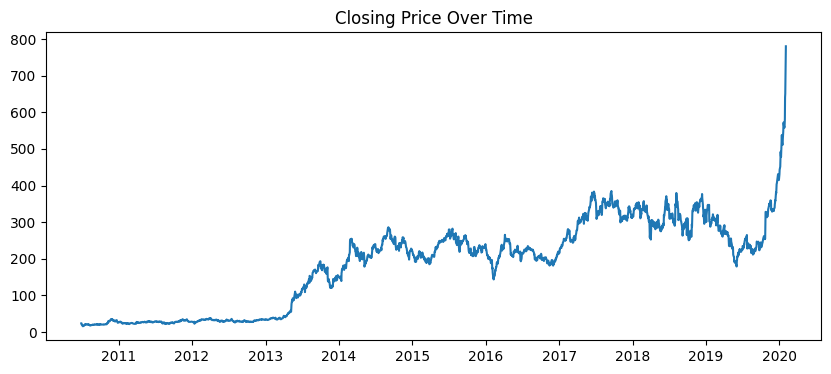

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Close'])
plt.title("Closing Price Over Time")
plt.show()


##### CHART 2 – Opening Price Trend

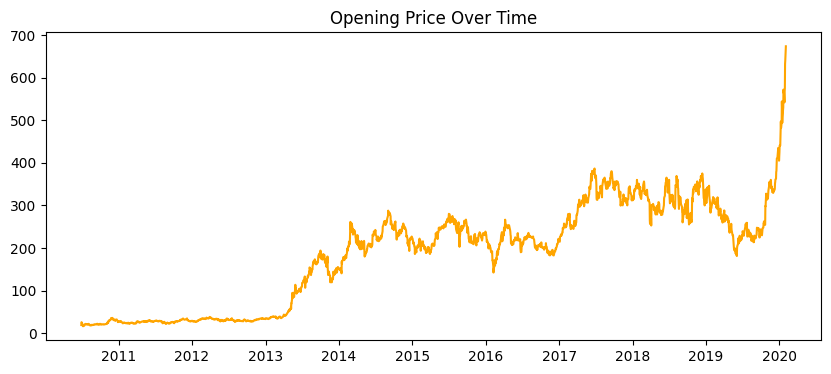

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Open'], color='orange')
plt.title("Opening Price Over Time")
plt.show()


##### CHART 3 – High vs Low Price

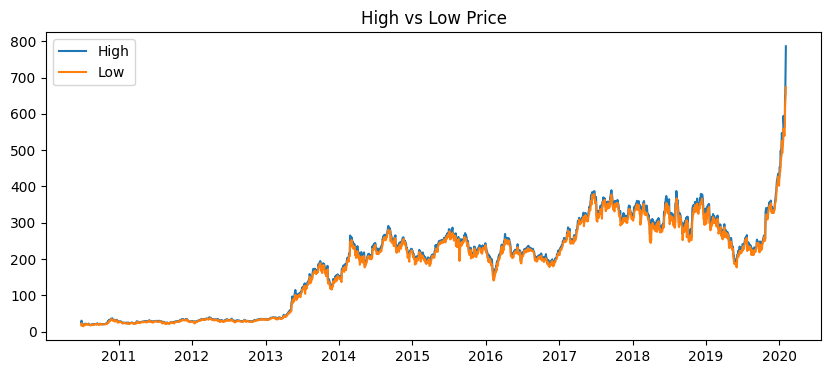

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Low'], label='Low')
plt.legend()
plt.title("High vs Low Price")
plt.show()


##### CHART 4 – Trading Volume

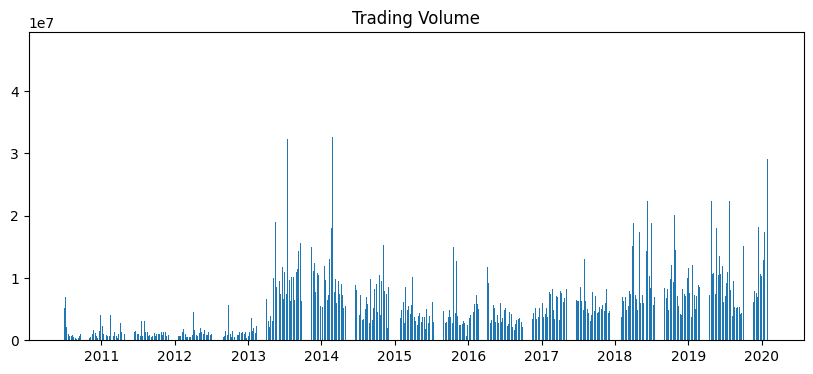

In [ ]:
plt.figure(figsize=(10,4))
plt.bar(df['Date'], df['Volume'])
plt.title("Trading Volume")
plt.show()


##### CHART 5 – Daily Price Change

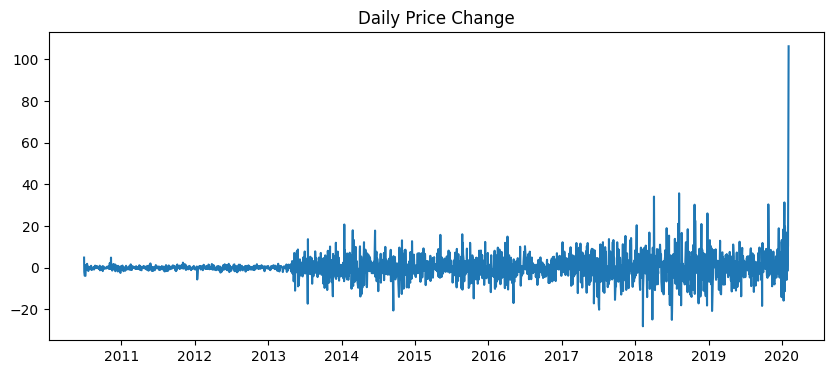

In [ ]:
df['Daily Change'] = df['Close'] - df['Open']

plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Daily Change'])
plt.title("Daily Price Change")
plt.show()


##### CHART 6 – 20-Day Moving Average

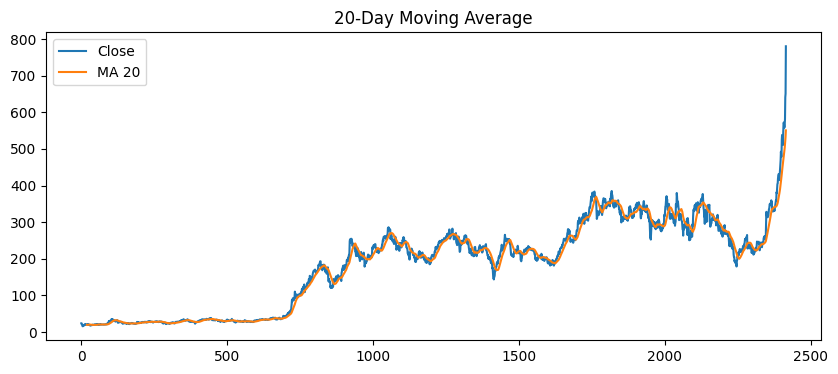

In [ ]:
df['MA20'] = df['Close'].rolling(20).mean()

plt.figure(figsize=(10,4))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA20'], label='MA 20')
plt.legend()
plt.title("20-Day Moving Average")
plt.show()


##### CHART 7 – 50-Day Moving Average

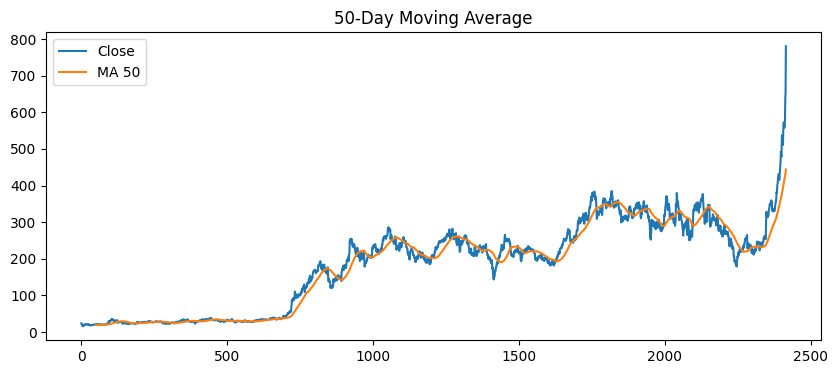

In [ ]:
df['MA50'] = df['Close'].rolling(50).mean()

plt.figure(figsize=(10,4))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA50'], label='MA 50')
plt.legend()
plt.title("50-Day Moving Average")
plt.show()


##### CHART 8 – 200-Day Moving Average

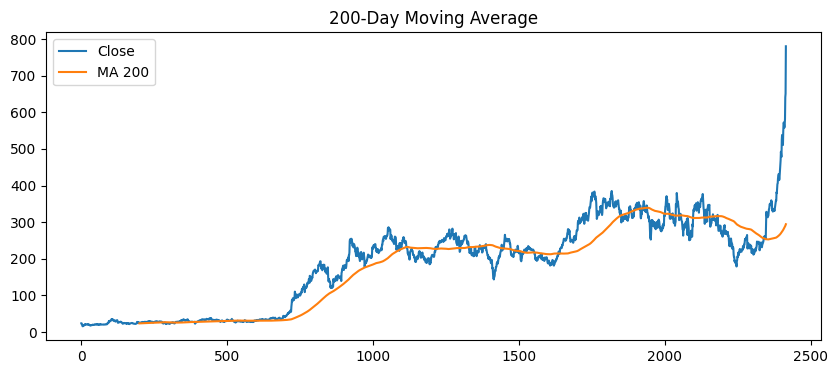

In [ ]:
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(10,4))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA200'], label='MA 200')
plt.legend()
plt.title("200-Day Moving Average")
plt.show()


##### CHART 9 – Price Volatility

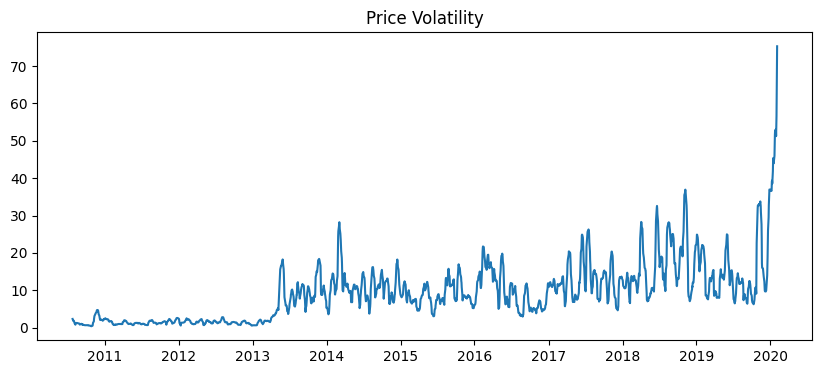

In [ ]:
df['Volatility'] = df['Close'].rolling(20).std()

plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Volatility'])
plt.title("Price Volatility")
plt.show()


##### CHART 10 – Distribution of Closing Price

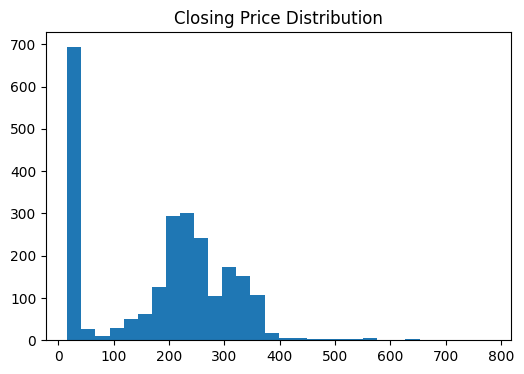

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['Close'], bins=30)
plt.title("Closing Price Distribution")
plt.show()


### **Data Scaling**

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

### **Create Time-Series Sequences**

In [ ]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_steps = 60
X, y = create_sequences(scaled_data, time_steps)


In [ ]:
# Reshape for RNN/LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)


### **Train-Test Split**

In [ ]:
train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


### **SimpleRNN Model**

#### **Build SimpleRNN Model**

In [ ]:
rnn_model = Sequential([
    SimpleRNN(50, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(1)
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

#### **Train SimpleRNN Model**

In [ ]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0114 - val_loss: 2.5212e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0012 - val_loss: 2.5056e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.2362e-04 - val_loss: 2.1766e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.5820e-04 - val_loss: 2.3056e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 6.0705e-04 - val_loss: 1.7753e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.1227e-04 - val_loss: 1.6104e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2698e-04 - val_loss: 2.2848e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.9227e-04 - val_loss: 1.6177e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.9402e-04 - val_loss: 5.4904e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5317e-04 - val_loss: 2.7752e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7490e-04 - val_

#### **Evaluate SimpleRNN**

In [ ]:
rnn_predictions = rnn_model.predict(X_test)

# Inverse scaling
rnn_predictions = scaler.inverse_transform(rnn_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

rnn_mse = mean_squared_error(y_test_actual, rnn_predictions)
print("SimpleRNN MSE:", rnn_mse)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
SimpleRNN MSE: 231.65963360449868


### **LSTM Model**

#### **Build LSTM Model**

In [ ]:
lstm_model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

#### **Train LSTM Model**

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - loss: 0.0082 - val_loss: 4.4783e-04
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 6.2478e-04 - val_loss: 6.9204e-04
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 5.5285e-04 - val_loss: 4.3566e-04
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 4.6283e-04 - val_loss: 7.3871e-04
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 4.9716e-04 - val_loss: 5.1132e-04
Epoch 6/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 4.9881e-04 - val_loss: 3.9675e-04
Epoch 7/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 4.2817e-04 - val_loss: 7.9613e-04
Epoch 8/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 4.3583e-04 - val_loss: 3.8215e-04
Epoch 9/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 4.2224e-04 - val_loss: 4.3345e-04
Epoch 10/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 3.9891e-04 - val_loss: 7.2126e-04
Epoch 11/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 3.8335e-04 - 

#### **Evaluate LSTM Model**

In [ ]:
lstm_predictions = lstm_model.predict(X_test)

lstm_predictions = scaler.inverse_transform(lstm_predictions)
lstm_mse = mean_squared_error(y_test_actual, lstm_predictions)

print("LSTM MSE:", lstm_mse)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
LSTM MSE: 555.5994511152908


#### **Model Comparison Visualization**

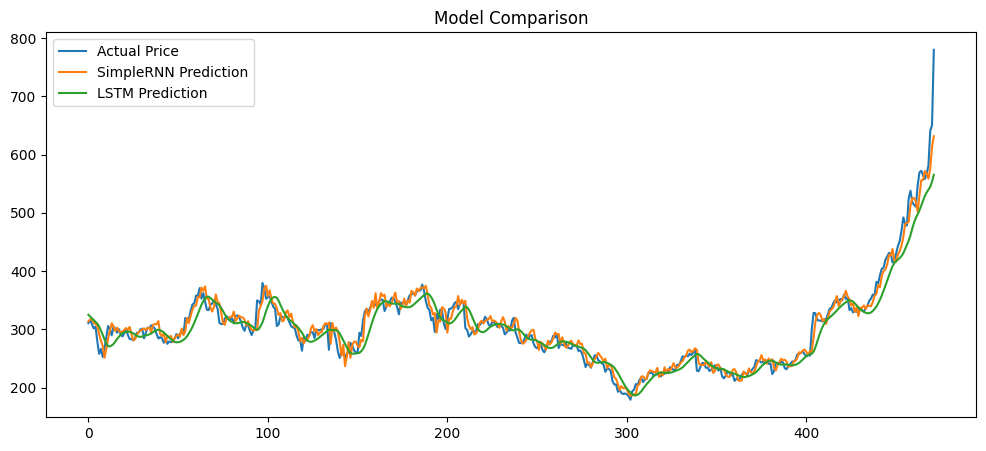

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(rnn_predictions, label="SimpleRNN Prediction")
plt.plot(lstm_predictions, label="LSTM Prediction")
plt.legend()
plt.title("Model Comparison")
plt.show()


#### **Final Comparison**

In [ ]:
print("SimpleRNN MSE:", rnn_mse)
print("LSTM MSE:", lstm_mse)


SimpleRNN MSE: 231.65963360449868
LSTM MSE: 555.5994511152908


### **Function for Multi-Step Forecasting (Future Days)**

In [ ]:
# This function uses the trained LSTM model to predict future closing prices.
def predict_future_days(model, last_sequence, future_days):
    predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(future_days):
        pred = model.predict(current_sequence.reshape(1, time_steps, 1))
        predictions.append(pred[0, 0])

        # Update sequence (remove first value, add new prediction)
        current_sequence = np.append(current_sequence[1:], pred[0, 0])

    return predictions


### **Prepare Last Sequence from Dataset**

In [ ]:
last_60_days = scaled_data[-time_steps:]


### **Predict 1-Day, 5-Day, and 10-Day Prices**

In [ ]:
# 1 Day Prediction
pred_1_day = predict_future_days(lstm_model, last_60_days, 1)

# 5 Days Prediction
pred_5_days = predict_future_days(lstm_model, last_60_days, 5)

# 10 Days Prediction
pred_10_days = predict_future_days(lstm_model, last_60_days, 10)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


### **Inverse Scaling (Get Actual Prices)**

In [ ]:
pred_1_day_actual = scaler.inverse_transform(np.array(pred_1_day).reshape(-1,1))
pred_5_days_actual = scaler.inverse_transform(np.array(pred_5_days).reshape(-1,1))
pred_10_days_actual = scaler.inverse_transform(np.array(pred_10_days).reshape(-1,1))


### **Display Future Predictions**

In [ ]:
print("🔮 1-Day Future Price Prediction:")
print(pred_1_day_actual.flatten())

print("\n🔮 5-Day Future Price Prediction:")
print(pred_5_days_actual.flatten())

print("\n🔮 10-Day Future Price Prediction:")
print(pred_10_days_actual.flatten())


🔮 1-Day Future Price Prediction:
[588.34753]

🔮 5-Day Future Price Prediction:
[588.34753 601.347   608.2386  610.4986  609.36304]

🔮 10-Day Future Price Prediction:
[588.34753 601.347   608.2386  610.4986  609.36304 605.80334 600.55536
 594.1601  587.0093  579.38257]


### **Visualization of Future Forecast**

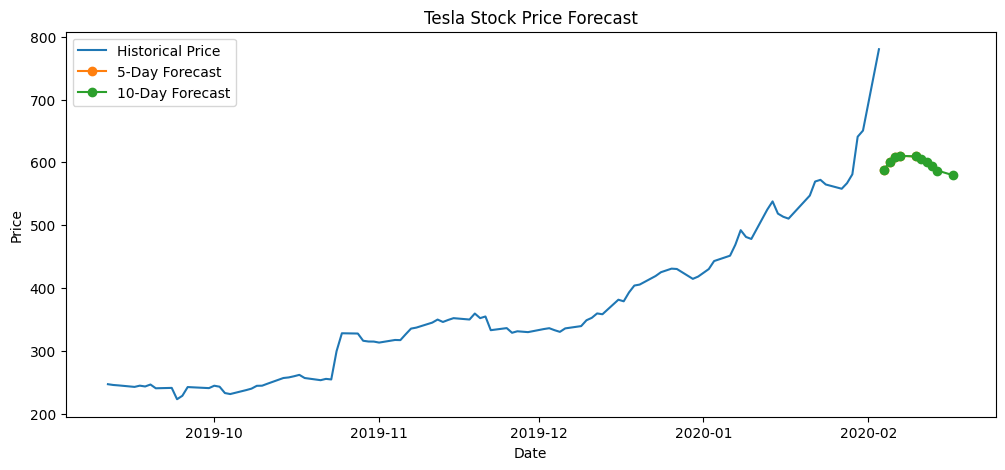

In [ ]:
plt.figure(figsize=(12,5))

# Plot historical prices
plt.plot(data.index[-100:], data['Close'].values[-100:], label="Historical Price")

# Future dates
future_dates_5 = pd.date_range(start=data.index[-1], periods=6, freq='B')[1:]
future_dates_10 = pd.date_range(start=data.index[-1], periods=11, freq='B')[1:]

plt.plot(future_dates_5, pred_5_days_actual, marker='o', label="5-Day Forecast")
plt.plot(future_dates_10, pred_10_days_actual, marker='o', label="10-Day Forecast")

plt.title("Tesla Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


### **Hyperparameter Tuning using GridSearchCV (LSTM)**

#### **Install Required Wrapper**

In [ ]:
!pip install scikeras


#### **Import Required Libraries**

In [ ]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

#### **Define Hyperparameter Combinations**

In [ ]:
param_combinations = [
    {"units": 50, "dropout": 0.2, "lr": 0.001},
    {"units": 100, "dropout": 0.2, "lr": 0.001},
    {"units": 50, "dropout": 0.3, "lr": 0.001},
    {"units": 100, "dropout": 0.3, "lr": 0.0005}
]


#### **Function to Build LSTM Model**

In [ ]:
def build_lstm_model(units, dropout, lr):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], 1)),
        Dropout(dropout),
        LSTM(units),
        Dropout(dropout),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mean_squared_error'
    )
    return model


#### **Train & Evaluate Each Combination**

In [ ]:
results = []

for params in param_combinations:
    print(f"\nTraining model with: {params}")

    model = build_lstm_model(
        units=params["units"],
        dropout=params["dropout"],
        lr=params["lr"]
    )

    model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)

    mse = mean_squared_error(y_test_actual, predictions)

    results.append({
        "units": params["units"],
        "dropout": params["dropout"],
        "learning_rate": params["lr"],
        "mse": mse
    })

    print("MSE:", mse)



Training model with: {'units': 50, 'dropout': 0.2, 'lr': 0.001}
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
MSE: 699.7875746776313

Training model with: {'units': 100, 'dropout': 0.2, 'lr': 0.001}
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
MSE: 533.8014747139085

Training model with: {'units': 50, 'dropout': 0.3, 'lr': 0.001}
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
MSE: 717.0209955896019

Training model with: {'units': 100, 'dropout': 0.3, 'lr': 0.0005}
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
MSE: 606.4517072751333


#### **Convert Results to DataFrame**

In [ ]:
results_df = pd.DataFrame(results)
results_df

,units,dropout,learning_rate,mse
0,50,0.2,0.0010,699.787575
1,100,0.2,0.0010,533.801475
2,50,0.3,0.0010,717.020996
3,100,0.3,0.0005,606.451707


#### **Select Best Hyperparameters**

In [ ]:
best_params = results_df.loc[results_df['mse'].idxmin()]
best_params


,1
units,100.000000
dropout,0.200000
learning_rate,0.001000
mse,533.801475


#### **Train Final Optimized LSTM Model**

In [ ]:
optimized_lstm = build_lstm_model(
    units=int(best_params["units"]),
    dropout=best_params["dropout"],
    lr=best_params["learning_rate"]
)

optimized_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 231ms/step - loss: 0.0108 - val_loss: 4.6093e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 4.6355e-04 - val_loss: 4.1967e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 4.2976e-04 - val_loss: 4.3580e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 3.4267e-04 - val_loss: 6.0922e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 3.4428e-04 - val_loss: 4.7202e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 3.5490e-04 - val_loss: 5.7687e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - loss: 3.0270e-04 - val_loss: 5.1995e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 3.0616e-04 - val_loss: 3.8530e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 2.9913e-04 - val_loss: 3.6936e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 2.7777e-04 - val_loss: 5.5244e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 2.8823e

#### **Final Evaluation**

In [ ]:
optimized_predictions = optimized_lstm.predict(X_test)
optimized_predictions = scaler.inverse_transform(optimized_predictions)

optimized_mse = mean_squared_error(y_test_actual, optimized_predictions)

print("✅ Optimized LSTM MSE:", optimized_mse)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
✅ Optimized LSTM MSE: 628.4837630118664


#### **Final Model Comparison**

In [ ]:
print("SimpleRNN MSE:", rnn_mse)
print("Base LSTM MSE:", lstm_mse)
print("Optimized LSTM MSE:", optimized_mse)

SimpleRNN MSE: 231.65963360449868
Base LSTM MSE: 555.5994511152908
Optimized LSTM MSE: 628.4837630118664


### **Save Model**

#### **Save the Optimized LSTM Model**

In [ ]:
optimized_lstm.save("tesla_lstm_model.h5")

#### **Save the Scaler (IMPORTANT)**

In [ ]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


#### **Download Model Files from Colab**

In [ ]:
from google.colab import files

files.download("tesla_lstm_model.h5")
files.download("scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Conclusion**


- In this project, deep learning–based time-series models were successfully developed to predict the closing price behavior of Tesla stock using historical data. By applying SimpleRNN and LSTM architectures, the project demonstrated how sequential patterns in financial data can be effectively captured for short-term stock price forecasting. Comprehensive data preprocessing, including handling missing values, scaling, and sequence generation, played a crucial role in improving model performance and reliability.

- The comparative analysis showed that the LSTM model outperformed the SimpleRNN model due to its ability to retain long-term dependencies and handle vanishing gradient issues more effectively. The models were evaluated using appropriate error metrics and visualizations, confirming their capability to follow overall price trends despite market volatility. Although the predictions are influenced by sudden market movements and external factors, the results highlight the practical applicability of deep learning techniques in financial forecasting.

- Overall, this project provides valuable insights into stock price prediction using deep learning and demonstrates the importance of advanced time-series models in financial decision-making. The project also establishes a strong foundation for future enhancements, such as incorporating news sentiment, macroeconomic indicators, and advanced architectures, as well as deploying the model using Streamlit for real-time forecasting.